<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [28]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-09 11:58:26--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
connected. to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... 
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.1’

survey-results-publ 100%[===================>] 201.62M  34.6MB/s    in 5.6s    

2026-03-09 11:58:34 (36.0 MB/s) - ‘survey-results-public.sqlite.1’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [29]:
!pip install pandas

In [30]:
!pip install matplotlib

In [45]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [32]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [33]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [34]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


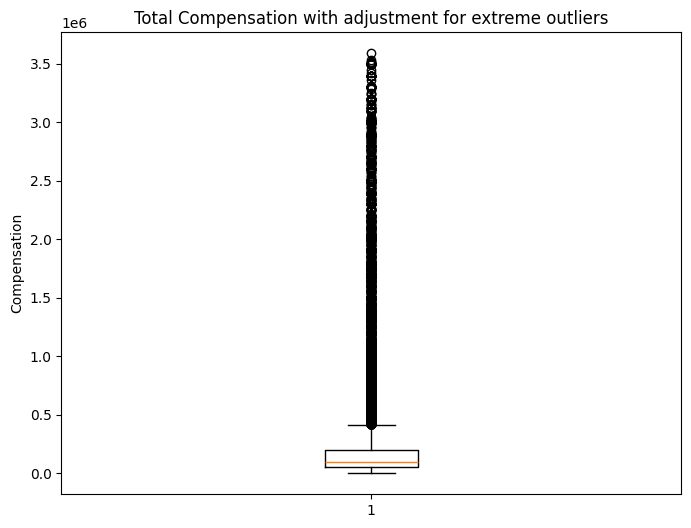

In [49]:
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL"
df = pd.read_sql_query(QUERY, conn)
q_high = df["CompTotal"].quantile(0.95)
df_filtered = df[df["CompTotal"] < q_high]
plt.figure(figsize=(8,6))
plt.boxplot(df_filtered['CompTotal'])
plt.title('Total Compensation with adjustment for extreme outliers')
plt.ylabel('Compensation')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


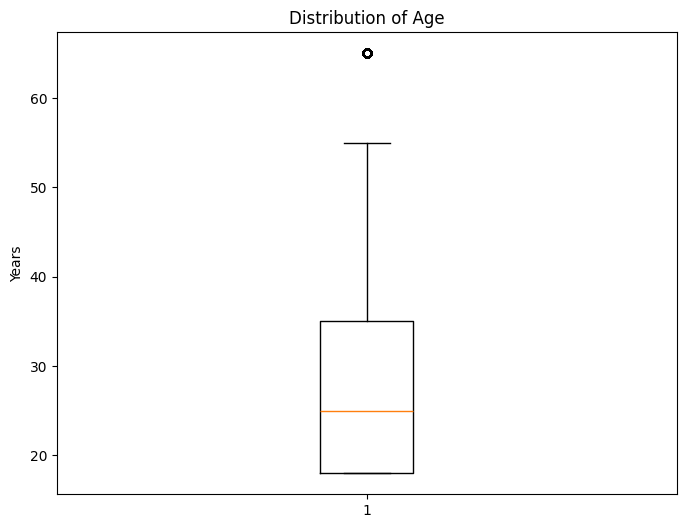

In [36]:
QUERY = "SELECT Age FROM main"
df = pd.read_sql_query(QUERY, conn)
df['AgeNumeric'] = df['Age'].str.extract('(\d+)').astype(float)
plt.figure(figsize=(8,6))
plt.boxplot(df['AgeNumeric'].dropna())
plt.title('Distribution of Age')
plt.ylabel('Years')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


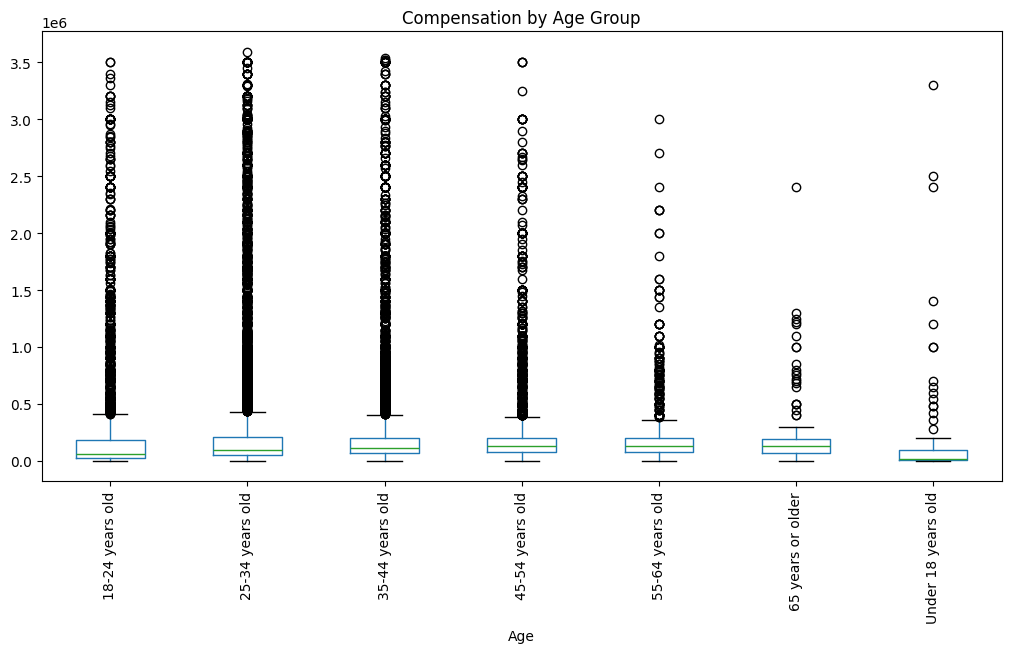

In [53]:
QUERY = "SELECT Age, CompTotal FROM main WHERE Age IS NOT NULL AND CompTotal IS NOT NULL"
df = pd.read_sql_query(QUERY, conn)
df = df[df['CompTotal'] < df['CompTotal'].quantile(0.95)]
df = df[df['Age'] != 'Prefer not to say']
df.boxplot(column='CompTotal', by='Age', figsize=(12,6), grid=False)
plt.title('Compensation by Age Group')
plt.suptitle('') 
plt.xticks(rotation=90)
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


<Figure size 1200x600 with 0 Axes>

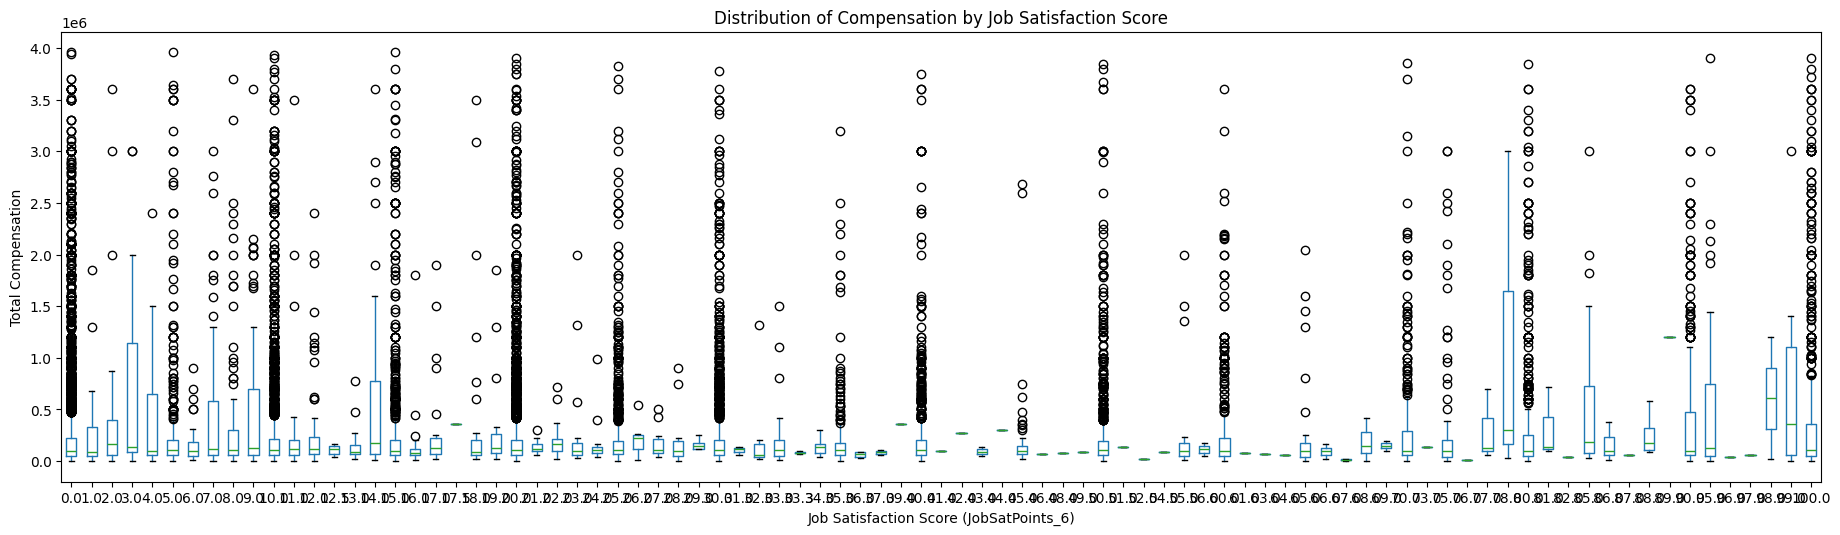

In [58]:
QUERY = """
SELECT JobSatPoints_6, CompTotal 
FROM main 
WHERE JobSatPoints_6 IS NOT NULL 
AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
q_limit = df['CompTotal'].quantile(0.95)
df_filtered = df[df['CompTotal'] < q_limit]
plt.figure(figsize=(12, 6))
df_filtered.boxplot(column='CompTotal', by='JobSatPoints_6', grid=False, figsize=(22,6))
plt.title('Distribution of Compensation by Job Satisfaction Score')
plt.suptitle('')
plt.xlabel('Job Satisfaction Score (JobSatPoints_6)')
plt.ylabel('Total Compensation')
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


<Figure size 1400x700 with 0 Axes>

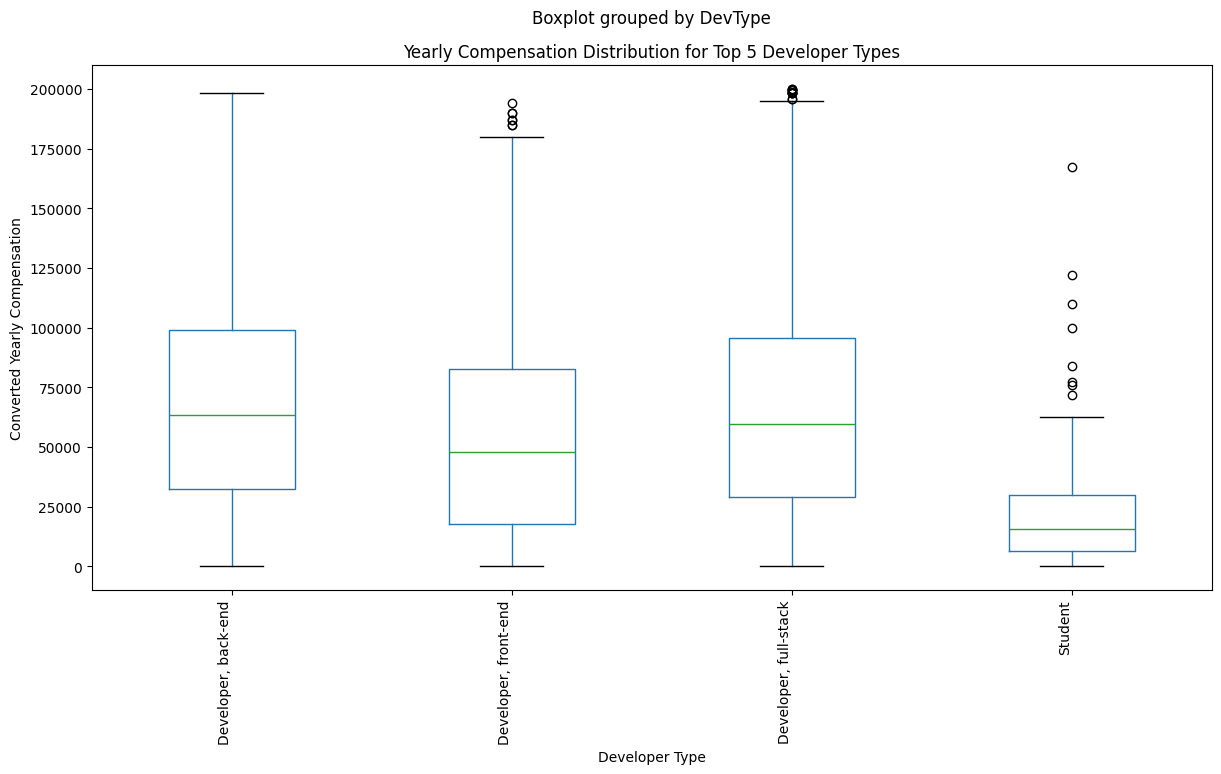

In [55]:
QUERY = """
SELECT DevType, ConvertedCompYearly 
FROM main 
WHERE DevType IN (
    SELECT DevType 
    FROM main 
    GROUP BY DevType 
    ORDER BY COUNT(*) DESC 
    LIMIT 5
) 
AND ConvertedCompYearly IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
q_limit = df['ConvertedCompYearly'].quantile(0.95)
df_filtered = df[df['ConvertedCompYearly'] < q_limit]
plt.figure(figsize=(14, 7))
df_filtered.boxplot(column='ConvertedCompYearly', by='DevType', grid=False, figsize=(14,7))
plt.title('Yearly Compensation Distribution for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('Converted Yearly Compensation')
plt.xticks(rotation=90, ha='right') 
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


<Figure size 1400x700 with 0 Axes>

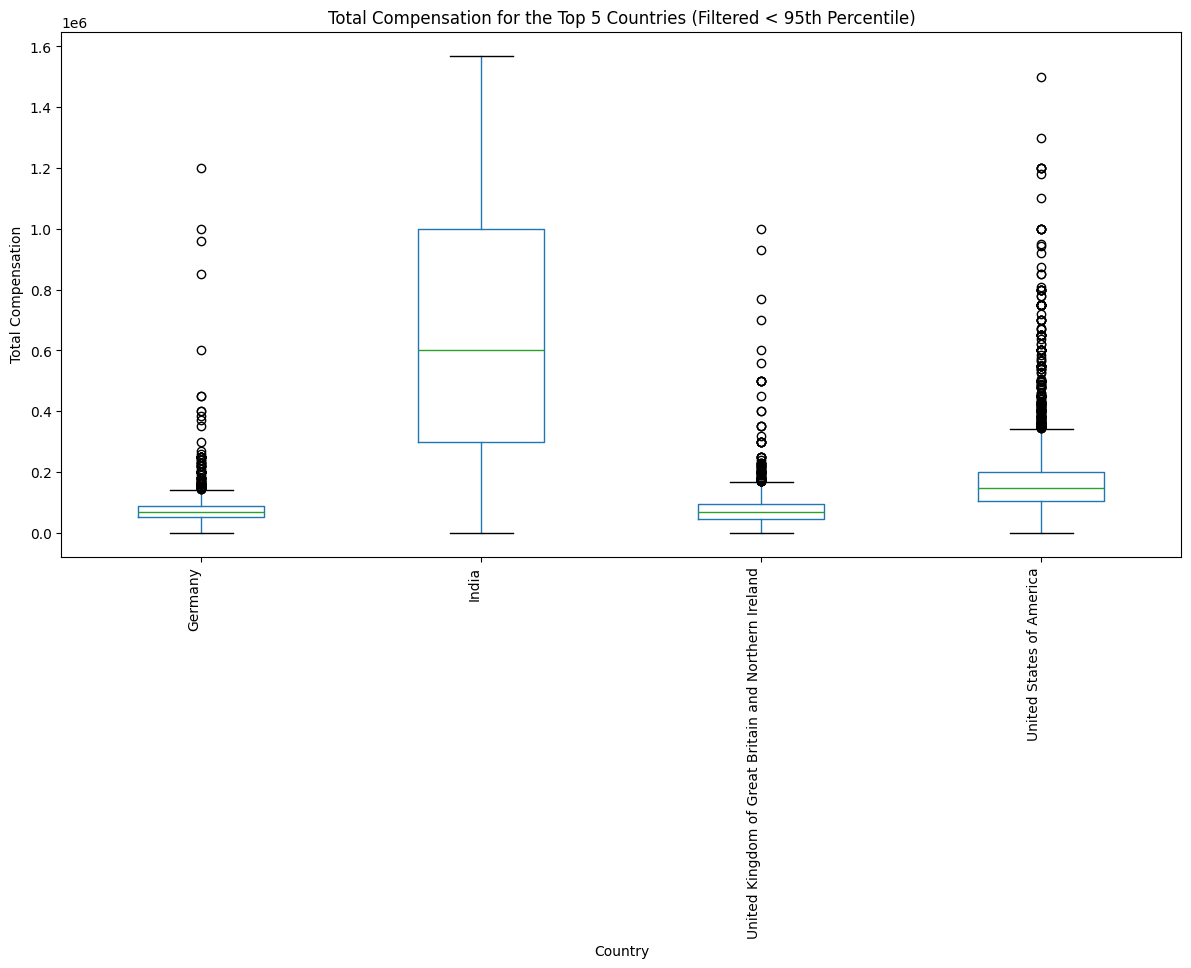

In [57]:
QUERY = """
SELECT Country, CompTotal 
FROM main 
WHERE Country IN (
    SELECT Country 
    FROM main 
    GROUP BY Country 
    ORDER BY COUNT(*) DESC 
    LIMIT 5
) 
AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
q_limit = df['CompTotal'].quantile(0.95)
df_filtered = df[df['CompTotal'] < q_limit]
plt.figure(figsize=(14, 7))
df_filtered.boxplot(column='CompTotal', by='Country', grid=False, figsize=(14,7))
plt.title('Total Compensation for the Top 5 Countries (Filtered < 95th Percentile)')
plt.suptitle('') 
plt.xlabel('Country')
plt.ylabel('Total Compensation')
plt.xticks(rotation=90, ha='right') 
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


<Figure size 1400x700 with 0 Axes>

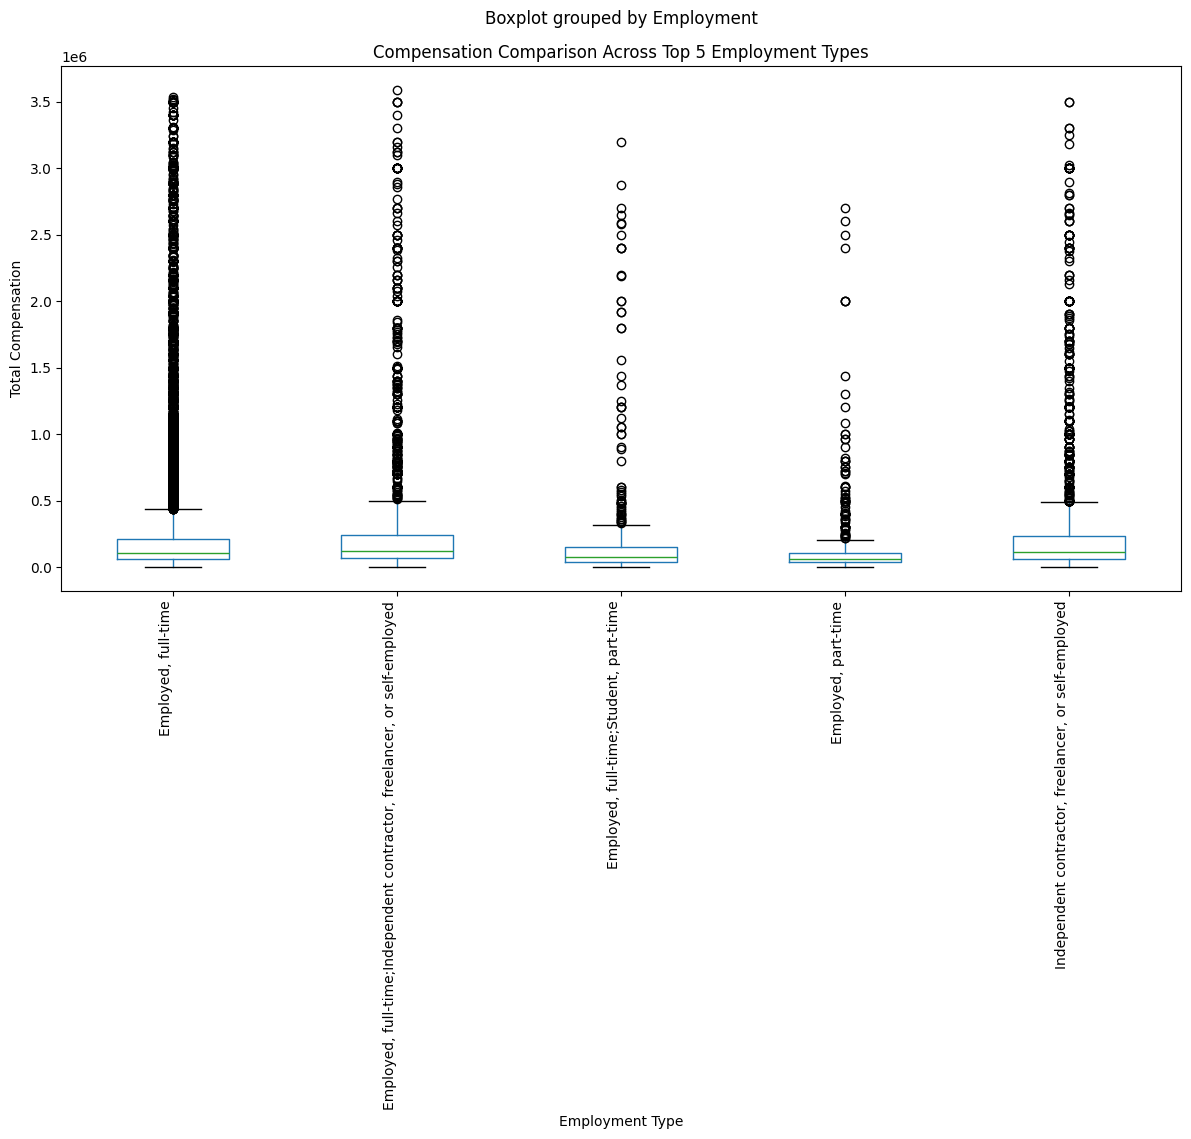

In [60]:
QUERY = """
SELECT Employment, CompTotal 
FROM main 
WHERE Employment IS NOT NULL 
AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
top_employment = df['Employment'].value_counts().nlargest(5).index
df_filtered_types = df[df['Employment'].isin(top_employment)]
q_limit = df_filtered_types['CompTotal'].quantile(0.95)
df_final = df_filtered_types[df_filtered_types['CompTotal'] < q_limit]
plt.figure(figsize=(14, 7))
df_final.boxplot(column='CompTotal', by='Employment', grid=False, figsize=(14,7))
plt.title('Compensation Comparison Across Top 5 Employment Types')
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation')
plt.xticks(rotation=90, ha='right')
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


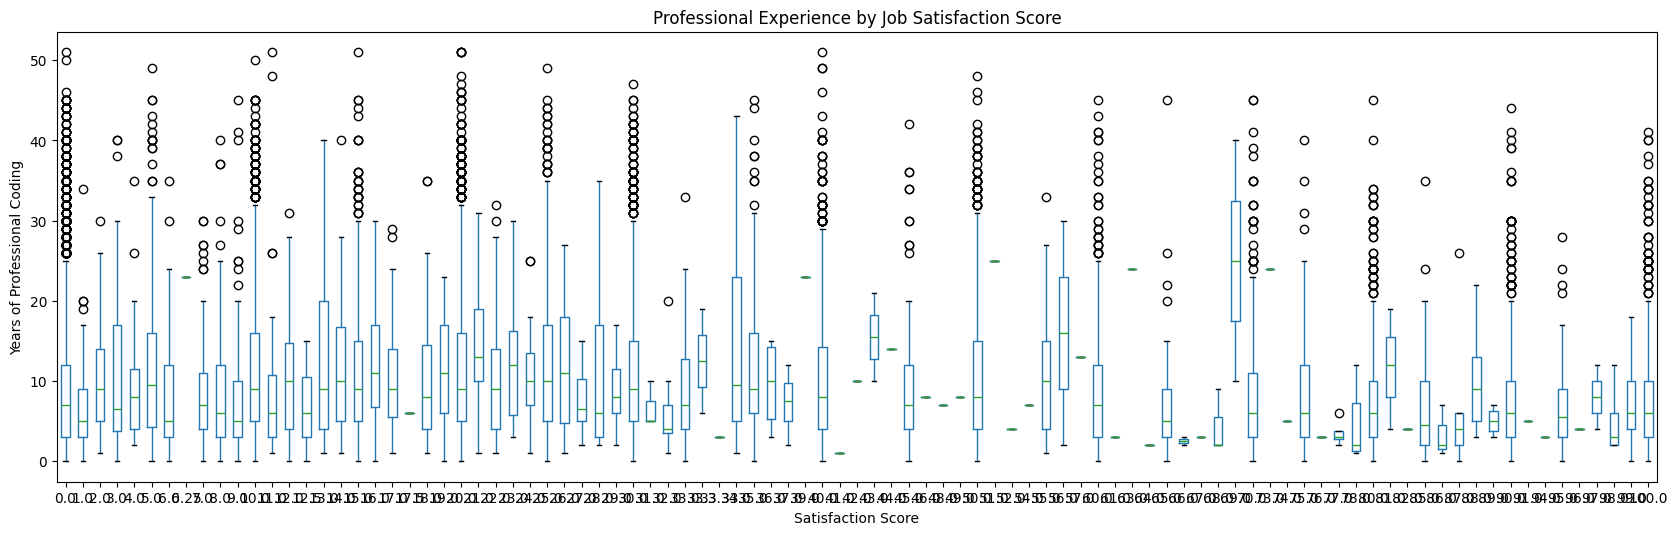

In [42]:
QUERY = "SELECT JobSatPoints_6, YearsCodePro FROM main"
df = pd.read_sql_query(QUERY, conn)
df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df.dropna(inplace=True)
df.boxplot(column='YearsCodePro', by='JobSatPoints_6', grid=False, figsize=(20,6))
plt.title('Professional Experience by Job Satisfaction Score')
plt.suptitle('')
plt.ylabel('Years of Professional Coding')
plt.xlabel('Satisfaction Score')
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [43]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
